In [25]:
%load_ext autoreload
%autoreload 2

In [26]:
import os

os.environ["TORCHDYNAMO_INLINE_INBUILT_NN_MODULES"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MUJOCO_GL"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_DEFAULT_MATMUL_PRECISION"] = "highest"


import random
import numpy as np
import torch
from torch.amp import autocast, GradScaler

torch.autograd.set_detect_anomaly(True)
torch.set_float32_matmul_precision("high")

from fast_td3.fast_td3_utils import (
    EmpiricalNormalization
)

from fast_td3.actors import ActorEGNN, Actor, ActorMPNN
from fast_td3.hyperparams import HumanoidBenchArgs

/home/thuaduc/.conda/envs/fasttd3_hb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
robot = "h1"

args = HumanoidBenchArgs(
    env_name=f"{robot}-run-v0",
    total_timesteps=150001,
    render_interval=5000,
    eval_interval=5000,
    num_envs=16,
    batch_size=8192,
    actor_hidden_dim=384,
    batch_size=8192,
    actor_hidden_dim=384,
)

In [28]:
amp_enabled = args.amp and args.cuda and torch.cuda.is_available()
amp_device_type = (
    "cuda"
    if args.cuda and torch.cuda.is_available()
    else "mps" if args.cuda and torch.backends.mps.is_available() else "cpu"
)
amp_dtype = torch.float

scaler = GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)
device = amp_device_type

random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.backends.cudnn.deterministic = args.torch_deterministic

print(f"Using device: {device}")

Using device: cuda


In [29]:
from fast_td3.environments.humanoid_bench_env import HumanoidBenchEnv

env_type = "humanoid_bench"
eval_envs = HumanoidBenchEnv(args.env_name, args.num_envs, device=device)
eval_envs = HumanoidBenchEnv(args.env_name, args.num_envs, device=device)
render_env = HumanoidBenchEnv(args.env_name, 1, render_mode="rgb_array", device=device)

n_act = render_env.num_actions
n_obs = render_env.num_obs if type(render_env.num_obs) == int else render_env.num_obs[0]
action_low, action_high = -1.0, 1.0

In [30]:
checkpoint_path = "./models/egnn_h1-run-v0_16envs_300001steps_3fa533_290000.pt"
obs_normalizer = EmpiricalNormalization(shape=n_obs, device=device)
xanchor_normalizer = EmpiricalNormalization(shape=(20, 3), device=device)
xanchor_normalizer = EmpiricalNormalization(shape=(20, 3), device=device)

# Actor setup
actor = ActorEGNN(
    n_obs=n_obs,
    n_act=n_act,
    num_envs=args.num_envs,
    batch_size=args.batch_size,
    device=device,
    init_scale=args.init_scale,
    hidden_dim=64,
    hidden_dim=64,
    n_layers=4,
    act_fn="relu",
    robot=robot,
    normalize=True, 
    coords_agg="mean"
)


torch_checkpoint = torch.load(
    f"{checkpoint_path}", map_location=device, weights_only=False
)
obs_normalizer.load_state_dict(torch_checkpoint["obs_normalizer_state"])
# xanchor_normalizer.load_state_dict(torch_checkpoint["xpos_normalizer_state"])
actor.load_state_dict(torch_checkpoint["actor_state_dict"])

normalize_obs = obs_normalizer.forward
# normalize_xanchor = xanchor_normalizer.forward

In [31]:
# checkpoint_path = "./models/mlp_h1-run-v0_16envs_200000steps_9a5637_final.pt"
# checkpoint_path = "./models/mlp_h1-run-v0_16envs_200000steps_9a5637_final.pt"
# obs_normalizer = EmpiricalNormalization(shape=n_obs, device=device)
# xanchor_normalizer = EmpiricalNormalization(shape=(20, 3), device=device)
# xanchor_normalizer = EmpiricalNormalization(shape=(20, 3), device=device)
# normalize_obs = obs_normalizer.forward
# normalize_xanchor = xanchor_normalizer.forward
# normalize_xanchor = xanchor_normalizer.forward

# actor = Actor(
# actor = Actor(
#     n_obs=n_obs,
#     n_act=n_act,
#     num_envs=args.num_envs,
#     device=device,
#     init_scale=args.init_scale,
#     hidden_dim=args.actor_hidden_dim,
#     hidden_dim=args.actor_hidden_dim,
# )

# torch_checkpoint = torch.load(
#     f"{checkpoint_path}", map_location=device, weights_only=False
# )
# obs_normalizer.load_state_dict(torch_checkpoint["obs_normalizer_state"])
# xanchor_normalizer.load_state_dict(torch_checkpoint["xpos_normalizer_state"])
# pretrained_state_dict = torch_checkpoint["actor_state_dict"]    
# actor.load_state_dict(torch_checkpoint["actor_state_dict"])

# normalize_obs = obs_normalizer.forward
# normalize_xanchor = xanchor_normalizer.forward

# torch_checkpoint = torch.load(
#     f"{checkpoint_path}", map_location=device, weights_only=False
# )
# obs_normalizer.load_state_dict(torch_checkpoint["obs_normalizer_state"])
# xanchor_normalizer.load_state_dict(torch_checkpoint["xpos_normalizer_state"])
# pretrained_state_dict = torch_checkpoint["actor_state_dict"]    
# actor.load_state_dict(torch_checkpoint["actor_state_dict"])

# normalize_obs = obs_normalizer.forward
# normalize_xanchor = xanchor_normalizer.forward

# print("actor parameters:", sum(p.numel() for p in actor.parameters()))

In [32]:
# num_eval_envs = eval_envs.num_envs
# episode_returns = torch.zeros(num_eval_envs, device=device)
# episode_lengths = torch.zeros(num_eval_envs, device=device)
# done_masks = torch.zeros(num_eval_envs, dtype=torch.bool, device=device)

# obs_normalizer.eval()
# xanchor_normalizer.eval()

# obs, xanchor = eval_envs.reset(random_position=False, random_orientation=False)
# for _ in range(eval_envs.max_episode_steps):
# 	with torch.no_grad(), autocast(
# 		device_type=amp_device_type, dtype=amp_dtype, enabled=amp_enabled
# 	):
# 		obs = normalize_obs(obs)
# 		xanchor = normalize_xanchor(xanchor)
# 		actions = actor.forward(obs, xanchor)

# 	next_obs, rewards, dones, _, next_xanchor = eval_envs.step(actions.float())
# 	episode_returns = torch.where(
# 		~done_masks, episode_returns + rewards, episode_returns
# 	)
# 	episode_lengths = torch.where(
# 		~done_masks, episode_lengths + 1, episode_lengths
# 	)
# 	done_masks = torch.logical_or(done_masks, dones)
# 	if done_masks.all():
# 		break
# 	obs = next_obs
# 	xanchor = next_xanchor


# print(episode_returns.mean().item(), episode_lengths.mean().item())

In [33]:
import tempfile
import imageio
import base64
from IPython.display import display, HTML


def frames_to_video_html(frames, fps=30):
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as temp_file:
        temp_filename = temp_file.name

    # Save frames as video
    imageio.mimsave(temp_filename, frames, fps=fps)

    # Read the video file and encode it to base64
    with open(temp_filename, "rb") as f:
        video_data = f.read()
    video_b64 = base64.b64encode(video_data).decode("utf-8")

    # Create HTML video element
    video_html = f"""
    <video width="640" height="480" controls>
        <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """

    # Clean up the temporary file
    os.unlink(temp_filename)

    return HTML(video_html)

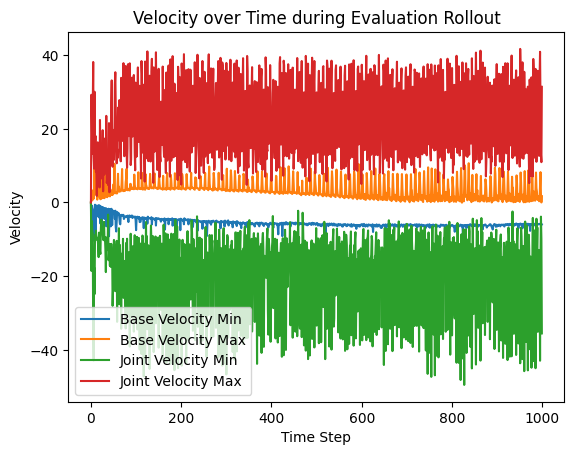

In [38]:
obs_normalizer.eval()
xanchor_normalizer.eval()

# Quick rollout for rendering
if env_type == "humanoid_bench":
	
	obs, xanchor = render_env.reset(random_position=True, random_orientation=True)
	
	renders = [render_env.render()]

	base_vel_min_history = []
	base_vel_max_history = []
	joint_vel_min_history = []
	joint_vel_max_history = []


for i in range(1000):
	with torch.no_grad(), autocast(
		device_type=amp_device_type, dtype=amp_dtype, enabled=amp_enabled
	):
		# Collect velocity statistics
		base_vel = obs[0, 26:32]
		joint_vel = obs[0, 32:]
		
		
		base_vel_min_history.append(base_vel.min().item())
		base_vel_max_history.append(base_vel.max().item())
		joint_vel_min_history.append(joint_vel.min().item())
		joint_vel_max_history.append(joint_vel.max().item())

		norm_obs = normalize_obs(obs)
		actions = actor(norm_obs, xanchor)

	next_obs, _, done, _, next_xanchor = render_env.step(actions.float())
	
	if i % 2 == 0:
		renders.append(render_env.render())

	if done.any():
		break
	obs = next_obs
	xanchor = next_xanchor

obs_normalizer.train()
xanchor_normalizer.train()
video_html = frames_to_video_html(renders, fps=30)
display(video_html)

import matplotlib.pyplot as plt

# distribution of velocities
plt.plot(base_vel_min_history, label="Base Velocity Min")
plt.plot(base_vel_max_history, label="Base Velocity Max")
plt.plot(joint_vel_min_history, label="Joint Velocity Min")
plt.plot(joint_vel_max_history, label="Joint Velocity Max")
plt.xlabel("Time Step")
plt.ylabel("Velocity")
plt.title("Velocity over Time during Evaluation Rollout")
plt.legend()
plt.show()

In [ ]:
render_with_rollout()